Random_state:  32
              precision    recall  f1-score   support

        Heal       0.73      0.89      0.80         9
         Not       0.80      0.57      0.67         7

    accuracy                           0.75        16
   macro avg       0.76      0.73      0.73        16
weighted avg       0.76      0.75      0.74        16

Accuracy: 75.0 %


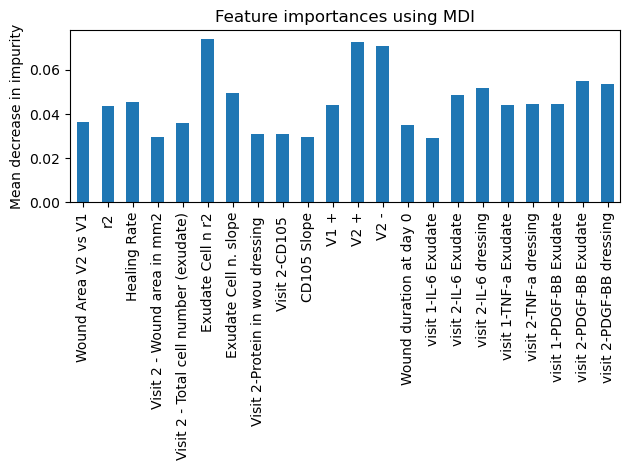

[[0.5595329  0.44046712]
 [0.49831128 0.5016887 ]
 [0.61601436 0.38398567]
 [0.60750467 0.39249533]
 [0.60904086 0.3909591 ]
 [0.6655402  0.3344598 ]
 [0.5734188  0.4265812 ]
 [0.66864604 0.33135396]
 [0.40368593 0.5963141 ]
 [0.7704168  0.22958319]
 [0.49755824 0.50244176]
 [0.4970045  0.5029955 ]
 [0.6476531  0.35234693]
 [0.46384752 0.5361525 ]
 [0.6095967  0.39040327]
 [0.5684437  0.43155628]]


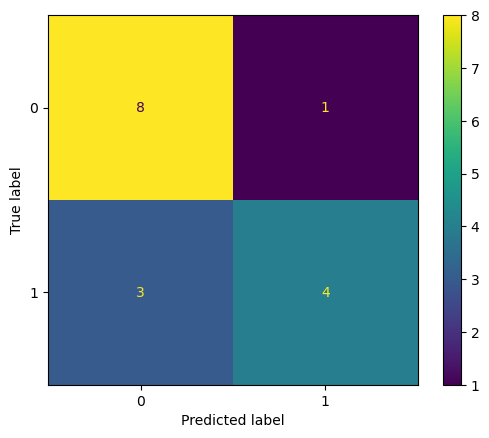

<Figure size 40000x12000 with 0 Axes>

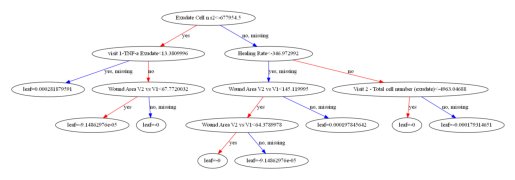

              precision    recall  f1-score   support

        Heal       0.97      1.00      0.99        36
         Not       1.00      0.96      0.98        27

    accuracy                           0.98        63
   macro avg       0.99      0.98      0.98        63
weighted avg       0.98      0.98      0.98        63

--------------------------------------------------------------------------------------------------


In [47]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model

W_tree=0


Treatment=pd.read_csv("../AD report/V2_change_train.csv")
Treatment_test=pd.read_csv("../AD report/V2_change_test.csv")


X_train=Treatment.iloc[:,1:]
y_train=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
y_test=Treatment_test.iloc[:,0]



#y_train = to_categorical(y_train)
#y_test = to_categorical(y_test)




R_state=random.randrange(1,100)
print("Random_state: ",R_state)
#R_state=63


clf=XGBClassifier(booster="dart",
                  normalize_type="tree",
                  tree_method="hist",
                    objective="reg:pseudohubererror",
                  eta=0.01,
                 # max_depth=4,
                  subsample=0.6,
                  colsample_bytree=0.8,
                 # colsample_bylevel=0.9,
                 #colsample_bynode=0.7,
                  reg_lambda=0.5,
                  reg_alpha=0.3,
                 # rate_drop=1,
                  skip_drop=0.2,
                  one_drop=1,
                  #  random_state=R_state,
                  max_bin=2056,
                num_parallel_tree=25,
  
                  sample_type="weighted",
                
                  
                  
                  
    )






clf.fit(X_train, y_train)
y_pred = clf.predict(X_test, iteration_range=(0, 100))
y_pred = (y_pred > 0.5) 


class_names=["Heal","Not"]

print(classification_report(y_test,y_pred,output_dict=False,target_names=class_names))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names
importances = clf.feature_importances_


forest_importances = pd.Series(importances, index=names)
#forest_importances = pd.Series(importances)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()

y_pred = clf.predict(X_train)
y_pred = (y_pred > 0.5) 
print(classification_report(y_train,y_pred,output_dict=False,target_names=class_names))

print("--------------------------------------------------------------------------------------------------")

target = 'key'

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_test, 
    y_test, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)